### ENSIMAG – Grenoble INP – UGA - Academic year 2025-2026
# Introduction to Statistical Learning and Applications ([website](https://github.com/ISLA-Grenoble/2025-main))

- Pedro L. C. Rodrigues -- `pedro.rodrigues@inria.fr`

- Isabella Costa Maia -- `isabella.costa-maia@grenoble-inp.fr`

- Pierre Marrec -- `pierre.marrec@inria.fr`

***

### ⚠️ General guidelines for TPs

Each team shall upload its report on their repository before the deadline indicated at the course website. Please
**include the name of all members** of the team on top of your report.
The report should contain graphical representations and explanatory text. For each graph, axis names should be provided as well
as a legend when it is appropriate. Figures should be explained by a few sentences in the text. Answer to
the questions in order and refer to the question number in your report. Computations and
graphics have to be performed in `python`. The report should be written as a jupyter notebook. This is a file format that allows users to format documents containing text written in markdown and `python` instructions. You should include all of the `python` instructions that you have used in the document so that it may be possible to replicate your results.

***

# 🖥️ TP3: Benchmarking classification methods

In this TP, we will be using mostly the packages `numpy`, `sklearn`, and `matplotlib`.

## ▶️ Part 1: Simulated data

Consider a simulated dataset generated as follows:

----
### -- Step 1
For each data point $i$, sample its label from a Bernoulli distribution $y_i \sim \mathcal{B}(p)$, i.e. $y_i = 1$ with probability $p$ and $y_i = 0$ with probability $1-p$. Note that to sample a random variable $B$ from $\mathcal{B}(p)$ you can first sample $U$ from an uniform distribution as in `U = numpy.random.rand()` and then note that $B = \mathbf{1}(U < p)$ where $\mathbf{1}(\cdot)$ is an indicator function.

### -- Step 2

Then, depending on the label $y_i \in \{0, 1\}$ the associated data point $\mathbf{x}_i \in \mathbb{R}^2$ is sampled as follows:

$$
  \mathbf{x}_i \mid y_i = 0 \sim \mathcal{N}(\boldsymbol{\mu}_0, \boldsymbol{\Sigma}_0) \quad \text{and} \quad \mathbf{x}_i \mid y_i = 1 \sim \mathcal{N}(\boldsymbol{\mu}_1, \boldsymbol{\Sigma}_1)
$$

where $\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$ is a multivariate normal distribution with mean $\boldsymbol{\mu}$ and covariance matrix $\boldsymbol{\Sigma}$ with pdf

$$
p_{\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})}(x) = \dfrac{1}{2\pi\sqrt{\det{\boldsymbol{\Sigma}}}}\exp\left(-\dfrac{1}{2}\big(\boldsymbol{x}-\boldsymbol{\mu}\big)^\top \boldsymbol{\Sigma}^{-1}\big(\boldsymbol{x}-\boldsymbol{\mu}\big)\right)
$$
and
$$
\boldsymbol{\mu}_0 = \left[\begin{array}{c}0 \\ 0\end{array}\right] \quad \boldsymbol{\mu}_1 = \left[\begin{array}{c}\varepsilon \\ 0\end{array}\right] \quad \boldsymbol{\Sigma}_0 = \left[\begin{array}{cc}0.5 & 0 \\ 0 & 0.5\end{array}\right] \quad \boldsymbol{\Sigma}_1 = \left[\begin{array}{cc}0.4 & 0 \\ 0 & 0.4\end{array}\right]
$$

Note that to sample a $p$-dimensional vector $\mathbf{x}$ from $\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$, you can use function `numpy.random.multivariate_normal`.

----

We will denote a set of $N$ data points $\{(\mathbf{x}_i, y_i)\}_{i = 1}^N$ simulated with $\varepsilon$ and $p$ as $\mathcal{D}(N \mid \varepsilon, p)$. 

Define two datasets:
$$
\mathcal{D}_\text{train} = \mathcal{D}(50 \mid 2, 0.30) \quad \text{and} \quad \mathcal{D}_{\text{test}} = \mathcal{D}(10^3 \mid 2, 0.30)~.
$$

**(a)** Plot the data points in $\mathcal{D}_\text{train} \cup \mathcal{D}_\text{test}$ using different colors to indicate the classes of each data point and different pointing symbols to indicate whether a point is from the train or test set. You should use `matplotlib`'s function for scatterplots. Remember to always include a legend in your figure.

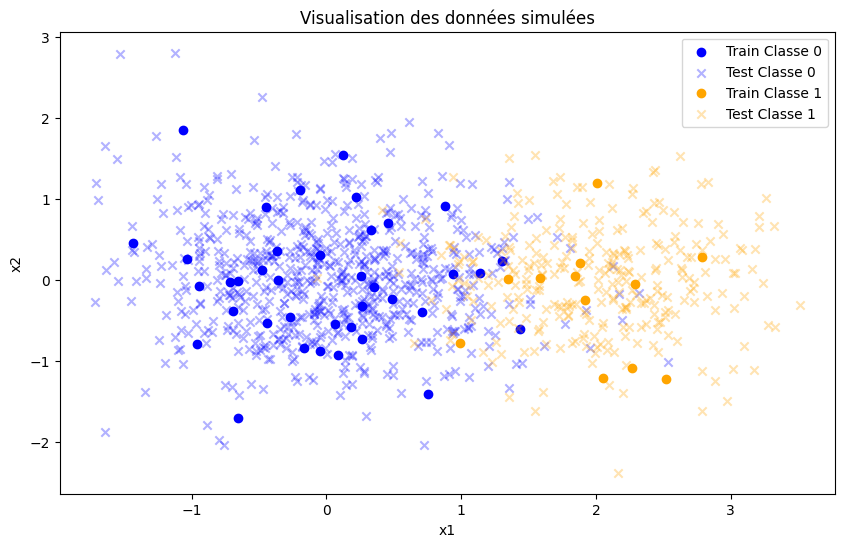

In [202]:
import numpy as np
import matplotlib.pyplot as plt

def generate_data(N, epsilon, p):
    y = np.array([1 if np.random.rand() < p else 0 for i in range(N)])
    
    X = np.zeros((N, 2))
    mu0, sigma0 = [0, 0], [[0.5, 0], [0, 0.5]]
    mu1, sigma1 = [epsilon, 0], [[0.4, 0], [0, 0.4]]
    
    for i in range(N):
        if y[i] == 0:
            X[i] = np.random.multivariate_normal(mu0, sigma0)
        else:
            X[i] = np.random.multivariate_normal(mu1, sigma1)
    return X, y

X_train, y_train = generate_data(50, 2, 0.3)
X_test, y_test = generate_data(1000, 2, 0.3)

# Plot
plt.figure(figsize=(10, 6))
for label, color in zip([0, 1], ['blue', 'orange']):
    # Train points (circle 'o')
    mask_train = (y_train == label)
    plt.scatter(X_train[mask_train, 0], X_train[mask_train, 1], c=color, marker='o', label=f'Train Classe {label}')
    # Test points (cross 'x')
    mask_test = (y_test == label)
    plt.scatter(X_test[mask_test, 0], X_test[mask_test, 1], c=color, marker='x', alpha=0.3, label=f'Test Classe {label}')

plt.legend()
plt.title("Visualisation des données simulées")
plt.xlabel("x1"); plt.ylabel("x2")
plt.show()

**(b)** What is the mathematical expression for the optimal Bayes classifier in this setting? And for its boundary region? Remember that the Bayes classifier can be written in terms of the ratio of $\text{Prob}(Y = 1 \mid \mathbf{x})$ over $\text{Prob}(Y = 0 \mid \mathbf{x})$ and that the values of $\mathbf{x} \in \mathbb{R}^2$ for which this ratio is 1 are those defining its boundary. Beware, however, that in this exercise we're considering $\text{Prob}(Y = 1) = p$ and $\text{Prob}(Y = 0) = 1-p$, so they are not necessarily always equal.

$$f(x) = argmax_k{P(Y = k \mid X = x)}$$

$$f(x) = 1 \implies \frac{P(Y = 1 \mid X = x)}{P(Y = 0 \mid X = x)} > 1$$

$$\frac{P(Y = 1 \mid X = x)}{P(Y = 0 \mid X = x)} > 1 \Leftrightarrow \frac{P(X = x) * P(Y = 1 \cap X = x)}{P(X = x) * P(Y = 0 \cap X = x)} > 1 \Leftrightarrow \frac{P(Y = 1 \cap X = x)}{P(Y = 0 \cap X = x)} > 1 \Leftrightarrow \frac{P(Y = 1) * P(X = x \mid Y = 1)}{P(Y = 0) * P(X = x \mid Y = 0)} > 1 $$

Donc

$$f(x) = \mathbb{1}_{\frac{p * P(X = x \mid Y = 1)}{(1 - p) * P(X = x \mid Y = 0)} > 1}$$


**(c)** Implement a Bayes classifier for this setup using scikit-learn's API as explained [here](https://scikit-learn.org/stable/developers/develop.html). This means that you will be writing a new classifier that follows the same logic and API as scikit-learn, but does not exist in the package. Use your implementation to estimate the error of the Bayes classifier on the samples from $\mathcal{D}(10^4 \mid 2, 0.3)$. How would you expect your results to change for other values of $\varepsilon$? Plot a curve showing how the Bayes error rate changes for different choices $\varepsilon$ (note that you will have to generate new datasets for this).

In [203]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.utils.validation import check_X_y, check_array, check_is_fitted
from sklearn.utils.multiclass import unique_labels
from sklearn.metrics import accuracy_score

class OptimalBayesClassifier(ClassifierMixin, BaseEstimator):
    def __init__(self, epsilon=2.0, p=0.30):
        self.epsilon = epsilon
        self.p = p

    def fit(self, X, y):
        # need to check
        X, y = check_X_y(X, y)
        
        # The classes
        self.classes_ = unique_labels(y)
        
        self.is_fitted_ = True 
        
        return self

    def predict(self, X):
        check_is_fitted(self, 'is_fitted_')
        X = check_array(X)
        
        # params of the 2 classes
        mu0 = np.array([0, 0])
        sigma0 = np.array([[0.5, 0], [0, 0.5]])
        
        mu1 = np.array([self.epsilon, 0])
        sigma1 = np.array([[0.4, 0], [0, 0.4]])
        
        # pdf estimation
        pdf0 = multivariate_normal.pdf(X, mean=mu0, cov=sigma0)
        pdf1 = multivariate_normal.pdf(X, mean=mu1, cov=sigma1)
        
        prob_1 = self.p * pdf1
        prob_0 = (1 - self.p) * pdf0
        
        predictions = (prob_1 > prob_0).astype(int)
        
        return self.classes_[predictions]

In [204]:
X_test_large, y_test_large = generate_data(N=10000, epsilon=2, p=0.3)

bayes_clf = OptimalBayesClassifier(epsilon=2, p=0.3)

bayes_clf.fit(X_test_large, y_test_large)

y_pred_large = bayes_clf.predict(X_test_large)

erreur_bayes = 1 - accuracy_score(y_test_large, y_pred_large)
print(f"Error (epsilon=2) : {erreur_bayes * 100:.2f}%")

Error (epsilon=2) : 6.15%


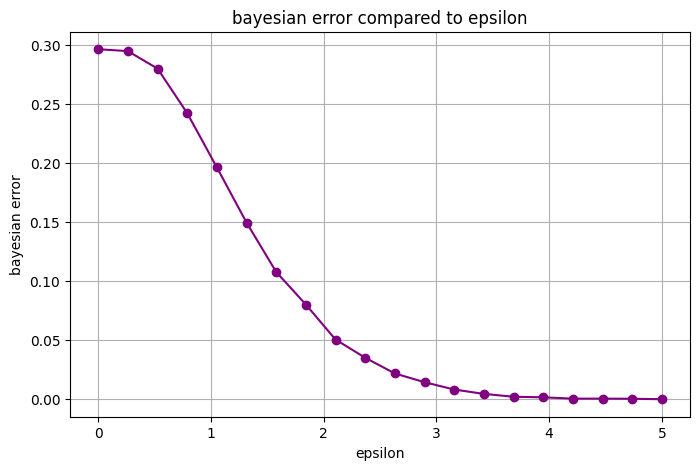

In [205]:
epsilons_a_tester = np.linspace(0, 5, 20) # 20 valeurs de 0 à 5
erreurs_theoriques = []

for eps in epsilons_a_tester:
    X_temp, y_temp = generate_data(N=10000, epsilon=eps, p=0.3)
    
    clf_temp = OptimalBayesClassifier(epsilon=eps, p=0.3)
    clf_temp.fit(X_temp, y_temp)
    
    y_pred_temp = clf_temp.predict(X_temp)
    erreur = 1 - accuracy_score(y_temp, y_pred_temp)
    
    erreurs_theoriques.append(erreur)

plt.figure(figsize=(8, 5))
plt.plot(epsilons_a_tester, erreurs_theoriques, marker='o', linestyle='-', color='purple')
plt.title("bayesian error compared to epsilon")
plt.xlabel("epsilon")
plt.ylabel("bayesian error")
plt.grid(True)
plt.show()

**(d)** Given the structure of the model generating the datasets, which classifier presented in our lectures seems to be the most adequate? Justify your answer in terms of the assumptions behind the construction of each classifier.

A QDA would be great since the variables have different covariance matrixes.

**(e)** Using `sklearn`, train a LDA, a QDA, and a logistic regression classifier on $\mathcal{D}_\text{train}$ and estimate their errors on the samples from $\mathcal{D}_\text{test}$. How do their errors compare to the value obtained in (c)? Can we expect the gap between the Bayes error rate and test error for each classifier change when the number of samples in $\mathcal{D}_{\text{train}}$ in change? Justify your answer both theoretically and empirically.

In [206]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lda = LinearDiscriminantAnalysis()
qda = QuadraticDiscriminantAnalysis()
log_reg = LogisticRegression()

lda.fit(X_train, y_train)
qda.fit(X_train, y_train)
log_reg.fit(X_train, y_train)

y_pred_lda = lda.predict(X_test)
y_pred_qda = qda.predict(X_test)
y_pred_logreg = log_reg.predict(X_test)

error_lda = 1 - accuracy_score(y_test, y_pred_lda)
error_qda = 1 - accuracy_score(y_test, y_pred_qda)
error_logreg = 1 - accuracy_score(y_test, y_pred_logreg)

print(f"Bayes error : {erreur_bayes:.3f}")
print(f"QDA error              : {error_qda:.3f}")
print(f"LDA error               : {error_lda:.3f}")
print(f"relog error   : {error_logreg:.3f}")

Bayes error : 0.061
QDA error              : 0.064
LDA error               : 0.066
relog error   : 0.074


**(f)** Consider a new test set defined as $\mathcal{D}'_\text{test} = \mathcal{D}(1000 \mid 0.5, 0.7)$. Use the same classifiers trained in (e) and estimate their new test errors. Do you observe any difference in the results? Can you explain what is happening?

In [207]:
X_test_2, y_test_2 = generate_data(N=1000, epsilon=0.5, p=0.7)

y_test_lda_2 = lda.predict(X_test_2)
y_test_qda_2 = qda.predict(X_test_2)
y_test_logreg_2 = log_reg.predict(X_test_2)
y_test_bayes_2 = bayes_clf.predict(X_test_2)

error_lda_2 = 1 - accuracy_score(y_test, y_test_lda_2)
error_qda_2 = 1 - accuracy_score(y_test, y_test_qda_2)
error_logreg_2 = 1 - accuracy_score(y_test, y_test_logreg_2)
error_bayes_2 = 1 - accuracy_score(y_test, y_test_bayes_2)

print(f"Bayes error : {error_bayes_2:.3f}")
print(f"QDA error               : {error_qda_2:.3f}")
print(f"LDA error               : {error_lda_2:.3f}")
print(f"relog error   : {error_logreg_2:.3f}")

Bayes error : 0.335
QDA error               : 0.330
LDA error               : 0.336
relog error   : 0.319


## ▶️ Part 2: Real data

In this part we will consider the Titanic dataset available [here](https://www.kaggle.com/competitions/titanic/data). The goal here will be to build a machine learning model that predicts which passengers survived the Titanic shipwreck. Each passenger (i.e., data point) is composed of a set of categorical and continuous features, and its labels are either 0 (dead) or 1 (survived).

First of all, you should download both the `training` and the `test` datasets.

-- The `training` set should be used to build your machine learning models. The labels for each passenger are provided. Your model will be based on “features” like passengers’ gender and class. You can also use feature engineering to create new features.

-- The `test` set should be used to see how well your model performs on unseen data. For the test set, we do not provide the ground truth for each passenger. It is your job to predict these outcomes. For each passenger in the test set, use the model you trained to predict whether or not they survived the sinking of the Titanic.

Follow the guidelines from [here](https://www.kaggle.com/competitions/titanic/overview) to understand how to submit the results of your predictions on the `test` set and obtain the score of your model.

### Suggestions:

-- Don't hesitate to do some exploratory data analysis before building your machine learning model. You chould check, for instance, which kind of cross-validator seems the most appropriate for assessing the score of your classifier : are the data points completely IID? are they ordered somehow? split into groups? Beware of all this.

-- Since you will be handling predictors with different data types, it might be useful to take a look at the concept of `ColumnTransformer` from scikit-learn [here](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html). You could also check these two videos about how to build complext pipelines [1](https://www.youtube.com/watch?v=7TZ7j4HSzmE) and [2](https://www.youtube.com/watch?v=lhMqqauXtW0).

-- Take a look at the package [`skrub`](https://skrub-data.org/stable/). You would be surprised with how easy it is to get a very good score on this dataset using `tabular_learner`.

In [208]:
import pandas as pd

train_data = pd.read_csv('./titanic/train.csv')
train_data.head()

# First, before starting we can remark many things by looking at the data. To fit our model,
# different features are not important for me at the beginning : PassengerId, Ticket, Cabin.

train_data.drop(columns=['PassengerId', 'Ticket', 'Cabin'], inplace=True)
train_data.head()
train_data.info()

train_data.describe()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    str    
 3   Sex       891 non-null    str    
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Fare      891 non-null    float64
 8   Embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(3)
memory usage: 62.8 KB


,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [209]:
# Let's see now the means of the different features for the 2 classes

pd.pivot_table(train_data, index='Survived', values=['Age', 'SibSp', 'Parch', 'Fare'])

# We can suppose that fare is really important for the survival of the passengers

# I delete now also the 2 lines where embarked is null
train_data.dropna(subset=['Embarked'], inplace=True)

In [210]:
# We can also see the rate of survival for different features

print(pd.pivot_table(train_data, index='Survived', columns='Pclass', values= 'Fare', aggfunc='count'))
print()
print(pd.pivot_table(train_data, index='Survived', columns='Sex', values= 'Fare', aggfunc='count'))
print()
print(pd.pivot_table(train_data, index='Survived', columns='SibSp', values= 'Fare', aggfunc='count'))
print()
print(pd.pivot_table(train_data, index='Survived', columns='Parch', values= 'Fare', aggfunc='count'))
print()
print(pd.pivot_table(train_data, index='Survived', columns='Embarked', values= 'Fare', aggfunc='count'))

# So, we can remark many things : if a passenger is at the first class, he has more
# chance to survive./ Females have more chance to survive./ If passengers have many
# siblings, they have less chance to survive. But if they don't have one also./
# If they don't have parents or children, they have less chance to survive./
# If they embarked from C they have more chance to survive, from S they have less chance.


Pclass      1   2    3
Survived              
0          80  97  372
1         134  87  119

Sex       female  male
Survived              
0             81   468
1            231   109

SibSp         0      1     2     3     4    5    8
Survived                                          
0         398.0   97.0  15.0  12.0  15.0  5.0  7.0
1         208.0  112.0  13.0   4.0   3.0  NaN  NaN

Parch         0     1     2    3    4    5    6
Survived                                       
0         445.0  53.0  40.0  2.0  4.0  4.0  1.0
1         231.0  65.0  40.0  3.0  NaN  1.0  NaN

Embarked   C   Q    S
Survived             
0         75  47  427
1         93  30  217


In [211]:
# Now I want to see if the name title (Mr, Mrs, Miss, etc.) can be important.
train_data['Title'] = train_data['Name'].apply(lambda x: x.split(',')[1].split('.')[0].strip())

print(pd.pivot_table(train_data, index='Survived', columns='Title', values= 'Fare', aggfunc='count'))

# So if you are a Mr you have less chance to survive, and if you are a miss or Mrs you have
# many chance to survive.

# now we can delete the name column because we have the title column now
train_data.drop(columns=['Name'], inplace=True)

Title     Capt  Col  Don   Dr  Jonkheer  Lady  Major  Master   Miss  Mlle  \
Survived                                                                    
0          1.0  1.0  1.0  4.0       1.0   NaN    1.0    17.0   55.0   NaN   
1          NaN  1.0  NaN  3.0       NaN   1.0    1.0    23.0  126.0   2.0   

Title     Mme     Mr   Mrs   Ms  Rev  Sir  the Countess  
Survived                                                 
0         NaN  436.0  26.0  NaN  6.0  NaN           NaN  
1         1.0   81.0  98.0  1.0  NaN  1.0           1.0  


In [212]:
# now let's separate data

from sklearn.model_selection import train_test_split

X = train_data.drop(columns=['Survived'])
y = train_data['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [213]:
# Now we need to fill the age with the mean age of the passengers, because we have many nan.

mean_age_train = X_train['Age'].mean()
X_train['Age'] = X_train['Age'].fillna(mean_age_train)
X_test['Age'] = X_test['Age'].fillna(mean_age_train)

# we will need it for the test_data
mean_fare_train = X_train['Fare'].mean()


# we have also to encode the categorical features, and to scale the numerical features
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

cat_cols = ['Sex', 'Embarked', 'Title']
num_cols = ['Age', 'SibSp', 'Parch', 'Fare']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        # handle_unknown='ignore' résout ton erreur de colonnes manquantes !
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ])

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)


In [214]:
# lets compare first differents basic models, then we will do a voting classifier

from sklearn.model_selection import cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC


gnb = GaussianNB()
logreg = LogisticRegression(max_iter=2000)
dt = DecisionTreeClassifier(random_state=0)
rf = RandomForestClassifier(random_state=0)
knn = KNeighborsClassifier()
svm = SVC(random_state=0, probability=True)

models = {
    'Naive Bayes': gnb,
    'Logistic Regression': logreg,
    'Decision Tree': dt,
    'Random Forest': rf,
    'KNN': knn,
    'SVM': svm}

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5)
    print(f"{name} : {scores}, {scores.mean()}")

# We see that the logistic regression and svm are the best models. The decision tree,
# random forest and knn are also good, so let's try a voting classifier with these 5 models.



Naive Bayes : [0.62937063 0.63380282 0.66197183 0.61267606 0.69014085], 0.6455924357332808
Logistic Regression : [0.84615385 0.87323944 0.82394366 0.78169014 0.88028169], 0.8410617551462621
Decision Tree : [0.78321678 0.88028169 0.77464789 0.72535211 0.81690141], 0.7960799763616665
Random Forest : [0.81818182 0.85915493 0.76760563 0.76760563 0.88028169], 0.8185659411011524
KNN : [0.82517483 0.86619718 0.8028169  0.76760563 0.85211268], 0.8227814439082046
SVM : [0.85314685 0.88028169 0.83802817 0.79577465 0.87323944], 0.848094159361765


In [215]:
votinclf = VotingClassifier(estimators=[
        ('lr', logreg), 
        ('arbre', dt), 
        ('foret', rf), 
        ('voisins', knn), 
        ('vecteurs', svm)
    ], voting='soft')
scores_voting = cross_val_score(votinclf, X_train, y_train, cv=5)
print(f"Voting Classifier : {scores_voting}, {scores_voting.mean()}")

# So it's a bit better than the best model but not too much.

Voting Classifier : [0.85314685 0.88028169 0.82394366 0.78873239 0.85211268], 0.8396434551364129


In [216]:
# I will try now to optimize the hyperparameters of the 5 models with a grid search
from sklearn.model_selection import GridSearchCV

param_grid_logreg = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs']
}

param_grid_dt = {
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

param_grid_rf = {
    'n_estimators': [300, 400, 500, 600],
    'max_depth': [None, 15, 20, 30]
}

param_grid_knn = {
    'n_neighbors': [9, 11, 13, 15],
}

param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf']
}

grid_logreg = GridSearchCV(logreg, param_grid_logreg, cv=5, scoring='accuracy')
grid_dt = GridSearchCV(dt, param_grid_dt, cv=5, scoring='accuracy')
grid_rf = GridSearchCV(rf, param_grid_rf, cv=5, scoring='accuracy')
grid_knn = GridSearchCV(knn, param_grid_knn, cv=5, scoring='accuracy')
grid_svm = GridSearchCV(svm, param_grid_svm, cv=5, scoring='accuracy')

grid_logreg.fit(X_train, y_train)
grid_dt.fit(X_train, y_train)
grid_rf.fit(X_train, y_train)
grid_knn.fit(X_train, y_train)
grid_svm.fit(X_train, y_train)

print(f"Best parameters for Logistic Regression: {grid_logreg.best_params_}")
print(f"Best parameters for Decision Tree: {grid_dt.best_params_}")
print(f"Best parameters for Random Forest: {grid_rf.best_params_}")
print(f"Best parameters for KNN: {grid_knn.best_params_}")
print(f"Best parameters for SVM: {grid_svm.best_params_}")

logreg_optimized = grid_logreg.best_estimator_
dt_optimized = grid_dt.best_estimator_
rf_optimized = grid_rf.best_estimator_
knn_optimized = grid_knn.best_estimator_
svm_optimized = grid_svm.best_estimator_


Best parameters for Logistic Regression: {'C': 1, 'solver': 'liblinear'}
Best parameters for Decision Tree: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 10}
Best parameters for Random Forest: {'max_depth': 15, 'n_estimators': 500}
Best parameters for KNN: {'n_neighbors': 15}
Best parameters for SVM: {'C': 1, 'kernel': 'rbf'}


In [217]:
# now we have the best parameters, let's try again the voting classifier
votinclf_optimized = VotingClassifier(estimators=[
        ('lr', logreg_optimized), 
        ('arbre', dt_optimized), 
        ('foret', rf_optimized), 
        ('voisins', knn_optimized), 
        ('vecteurs', svm_optimized)
    ], voting='soft')
scores_voting_optimized = cross_val_score(votinclf_optimized, X_train, y_train, cv=5)
print(f"Voting Classifier optimized : {scores_voting_optimized}, {scores_voting_optimized.mean()}")

Voting Classifier optimized : [0.84615385 0.88028169 0.82394366 0.78169014 0.87323944], 0.8410617551462621


In [218]:
# let's see the score of the optimized voting classifier on the test set
votinclf_optimized.fit(X_train, y_train)
y_pred_optimized = votinclf_optimized.predict(X_test)
accuracy_optimized = accuracy_score(y_test, y_pred_optimized)
print(f"Optimized Voting Classifier Accuracy on Test Set: {accuracy_optimized}")

Optimized Voting Classifier Accuracy on Test Set: 0.7471910112359551


In [221]:
# now let's create the final y_pred for the test set and submit it on kaggle
test_data = pd.read_csv('./titanic/test.csv')

test_data.drop(columns=['PassengerId', 'Ticket', 'Cabin'], inplace=True)
test_data['Title'] = test_data['Name'].apply(lambda x: x.split(',')[1].split('.')[0].strip())
test_data.drop(columns=['Name'], inplace=True)
test_data['Age'] = test_data['Age'].fillna(mean_age_train)
# there is a nan also in one column of fare
test_data['Fare'] = test_data['Fare'].fillna(mean_fare_train)
X_test_final = preprocessor.transform(test_data)



y_pred_final = votinclf_optimized.predict(X_test_final)

submit = pd.DataFrame({
    'PassengerId': pd.read_csv('./titanic/test.csv')['PassengerId'],
    'Survived': y_pred_final
})

submit.to_csv('submission.csv', index=False)



**(a)** Explain the feature engineering that you had to do with the dataset. If you've used `skrub`, explain how the encoding for each kind of predictor was decided.

I have explianed everything I have done, but firstly, I just deleted columns that seemed useless for me (ie cabin, ticket and passengerId).

Then, I created a column Title which contains Ms, Mr... and I deleted the name column.

**(b)** What type of classifier did you end up using? Why? What was your score in the public leaderboard from Kaggle?

I end up using a votingclassifier with a soft vote, with 5 classifiers (randomforest, logisticregression, DecisionTree, knn, svc) with the best hyperparameters selected from a gridsearchcv. My score in the public leaderboard is 0.77033. 

This score can be beaten by optimizing the feature engineering, like for example examining the numbers of people in a family. Also we could try to examine the ticket to see people in groups.